In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("ishank2005/nyc-housing-prices-csv")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\kochu\.cache\kagglehub\datasets\ishank2005\nyc-housing-prices-csv\versions\1


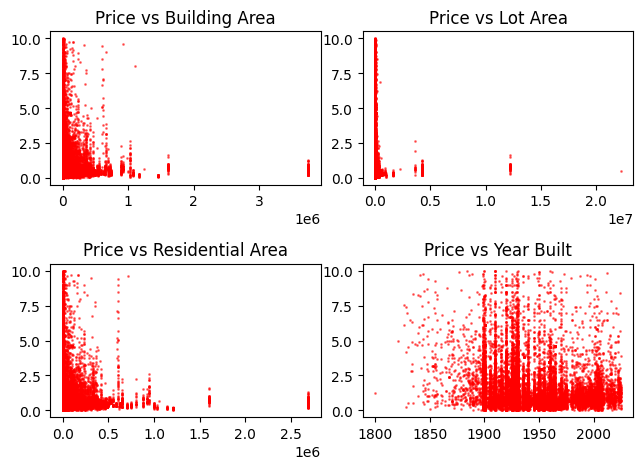

In [90]:
tset=pd.read_csv("nyc_housing_base.csv")

tset=tset[tset["sale_price"]>0]
tset=tset.dropna()
tset["sale_price"]=tset["sale_price"]/1000000

x=tset[["bldgarea","lotarea","resarea","yearbuilt"]].values
y=tset["sale_price"].values

x = (x - x.mean(axis=0)) / x.std(axis=0)

fig,axis=plt.subplots(2,2)
gch={"color":"red","alpha":0.5,"s":1}
axis[0,0].scatter(tset["bldgarea"],tset["sale_price"],**gch)
axis[0,0].set_title("Price vs Building Area")

axis[0,1].scatter(tset["lotarea"],tset["sale_price"],**gch)
axis[0,1].set_title("Price vs Lot Area")

axis[1,0].scatter(tset["resarea"],tset["sale_price"],**gch)
axis[1,0].set_title("Price vs Residential Area")

axis[1,1].scatter(tset["yearbuilt"],tset["sale_price"],**gch)
axis[1,1].set_title("Price vs Year Built")

plt.tight_layout()
plt.show()

In [91]:
def cost_fun(x,y,w,b):
    m=len(y)
    cost_sum=0
    for i in range(m):
        f=np.dot(x[i],w)+b
        cost=(f-y[i])**2
        cost_sum+=cost
    tot_cost=(1/(2*m))*cost_sum
    return tot_cost

In [92]:
def grad(x,y,w,b):
    m=len(x)
    dc_dw=np.zeros_like(w)
    dc_db=0
    for i in range(m):
        f=np.dot(x[i],w)+b
        dc_dw+=(x[i])*(f-y[i])
        dc_db+=(f-y[i])
    dc_dw=dc_dw/m
    dc_db=dc_db/m
    return dc_dw,dc_db

In [93]:
def grad_descent(x,y,alpha,iteration):
    w=np.zeros(x.shape[1])
    b=0
    cost_history=[]
    for i in range(iteration):
        dc_dw,dc_db=grad(x,y,w,b)
        w=w-(alpha*dc_dw)
        b=b-(alpha*dc_db)
        costd=cost_fun(x,y,w,b)
        cost_history.append(costd)
        # if i % 100 == 0:
        #     print(cost_fun(x,y,w,b))
    plt.plot(cost_history)
    plt.show()
    return w,b

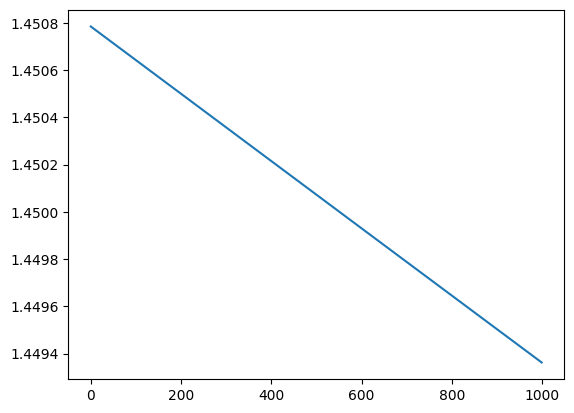

w= [-9.64540738e-05 -5.66057303e-05 -1.12076216e-04 -1.70208936e-04] b= 0.001170022777702423


In [94]:
alpha=1e-6
iteration=1000

final_w,final_b=grad_descent(x,y,alpha,iteration)

print("w=",final_w,"b=",final_b)

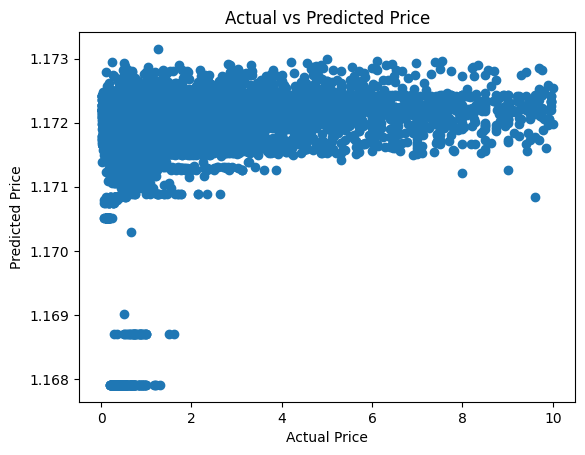

In [ ]:
# y_pred = np.dot(x, final_w) + final_b
# y_pred = y_pred * y.std() + y.mean()

# plt.scatter(y, y_pred)
# plt.xlabel("Actual Price")
# plt.ylabel("Predicted Price")
# plt.title("Actual vs Predicted Price")
# plt.show()